# Zero-Shot Image Classification (CLIP)

**CLIP** (Radford et al., 2021) — модель, обученная на 400M пар (изображение, текст).
Проецирует изображения и тексты в общее пространство эмбеддингов.

Для классификации:
1. Кодируем изображение → вектор
2. Кодируем текстовые описания классов → векторы
3. Косинусная близость → вероятности классов

$$\hat{y} = \arg\max_{k} \frac{\exp(\cos(f_{img}(x), f_{txt}(c_k)) / \tau)}{\sum_{k'} \exp(\cos(f_{img}(x), f_{txt}(c_{k'})) / \tau)}$$

**Не требует обучения** на целевых классах — true zero-shot.

In [5]:
!pip install -q transformers pillow requests torch

In [6]:
import requests
from io import BytesIO
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import torch
import matplotlib.pyplot as plt
import numpy as np

# Загрузка модели
print("Загрузка CLIP...")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()
print("Модель загружена.")

Загрузка CLIP...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена.


In [7]:
# === ССЫЛКИ НА ИЗОБРАЖЕНИЯ ===
image_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/4/45/A_small_cup_of_coffee.JPG",
]

# === КЛАССЫ И ОПИСАНИЯ (описания на английском — CLIP обучен на английском!) ===
classes = {
    "домашняя кошка": "a small domestic house cat with fur",
    "рысь": "a wild cat, lynx, medium-sized feline predator",
    "тигр": "a large striped wild cat, tiger",
    "лиса": "a fox, small wild canine with fluffy tail",
    "волк": "a wolf, wild canine predator",
    "собака": "a friendly domestic dog, pet",
    "лошадь": "a horse, large domestic animal for riding",
    "зебра": "a zebra, black and white striped horse-like animal",
    "осёл": "a donkey, grey sturdy working animal",
    "чай": "a cup of tea, hot beverage with leaves",
    "кофе": "a cup of coffee, dark hot drink with beans",
    "какао": "a cup of hot chocolate, sweet brown drink",
}


In [8]:
# Загрузка изображений
images = []
valid_urls = []
for url in image_urls:
    try:
        resp = requests.get(url, timeout=15, headers={"User-Agent": "Mozilla/5.0"})
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        images.append(img)
        valid_urls.append(url)
        print(f"  Загружено: {url[:80]}...")
    except Exception as e:
        print(f"  Ошибка: {url[:80]}... — {e}")

# Текстовые промпты
class_names = list(classes.keys())
text_prompts = [f"a photo of {desc}" for desc in classes.values()]

print(f"\nИзображений: {len(images)}, Классов: {len(class_names)}")

  Загружено: https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg...
  Загружено: https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jp...
  Загружено: https://upload.wikimedia.org/wikipedia/commons/4/45/A_small_cup_of_coffee.JPG...

Изображений: 3, Классов: 12


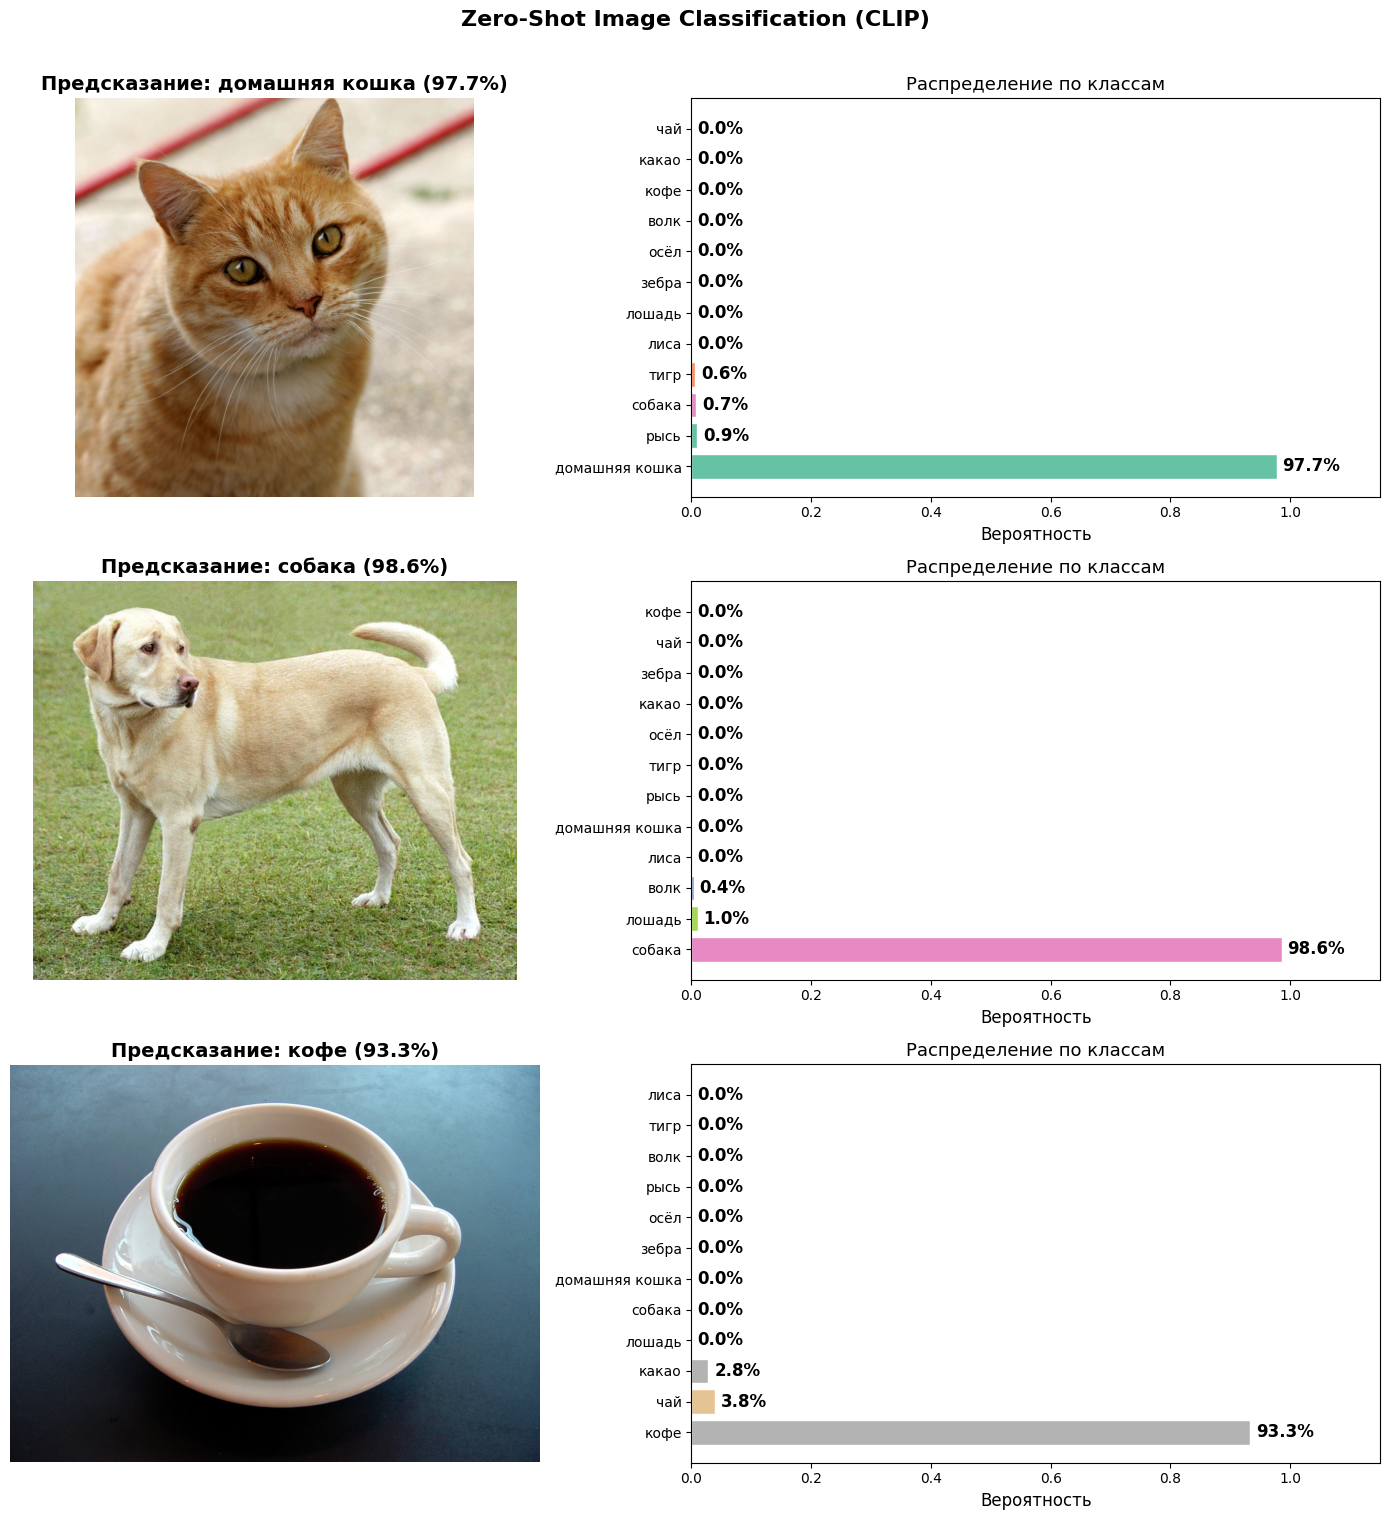

In [9]:
# Классификация и визуализация
n_images = len(images)
fig, axes = plt.subplots(n_images, 2, figsize=(14, 5 * n_images),
                         gridspec_kw={"width_ratios": [1, 1.3]})
if n_images == 1:
    axes = axes.reshape(1, -1)

colors = plt.cm.Set2(np.linspace(0, 1, len(class_names)))

for i, img in enumerate(images):
    inputs = processor(text=text_prompts, images=img, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = outputs.logits_per_image[0].softmax(dim=0).cpu().numpy()

    best_idx = probs.argmax()

    # Изображение
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Предсказание: {class_names[best_idx]} ({probs[best_idx]:.1%})",
                         fontsize=14, fontweight="bold")
    axes[i, 0].axis("off")

    # Барчарт вероятностей
    sorted_idx = np.argsort(probs)[::-1]
    bars = axes[i, 1].barh(
        [class_names[j] for j in sorted_idx],
        [probs[j] for j in sorted_idx],
        color=[colors[j] for j in sorted_idx],
        edgecolor="white",
    )
    for bar, j in zip(bars, sorted_idx):
        axes[i, 1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                        f"{probs[j]:.1%}", va="center", fontsize=12, fontweight="bold")
    axes[i, 1].set_xlim(0, 1.15)
    axes[i, 1].set_xlabel("Вероятность", fontsize=12)
    axes[i, 1].set_title("Распределение по классам", fontsize=13)

plt.suptitle("Zero-Shot Image Classification (CLIP)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Эксперимент 2: Размытые описания

Теперь заменим чёткие описания на **косвенные признаки** — без названий объектов. Модель должна «догадаться» по атрибутам. Это покажет, как качество описаний влияет на zero-shot классификацию.

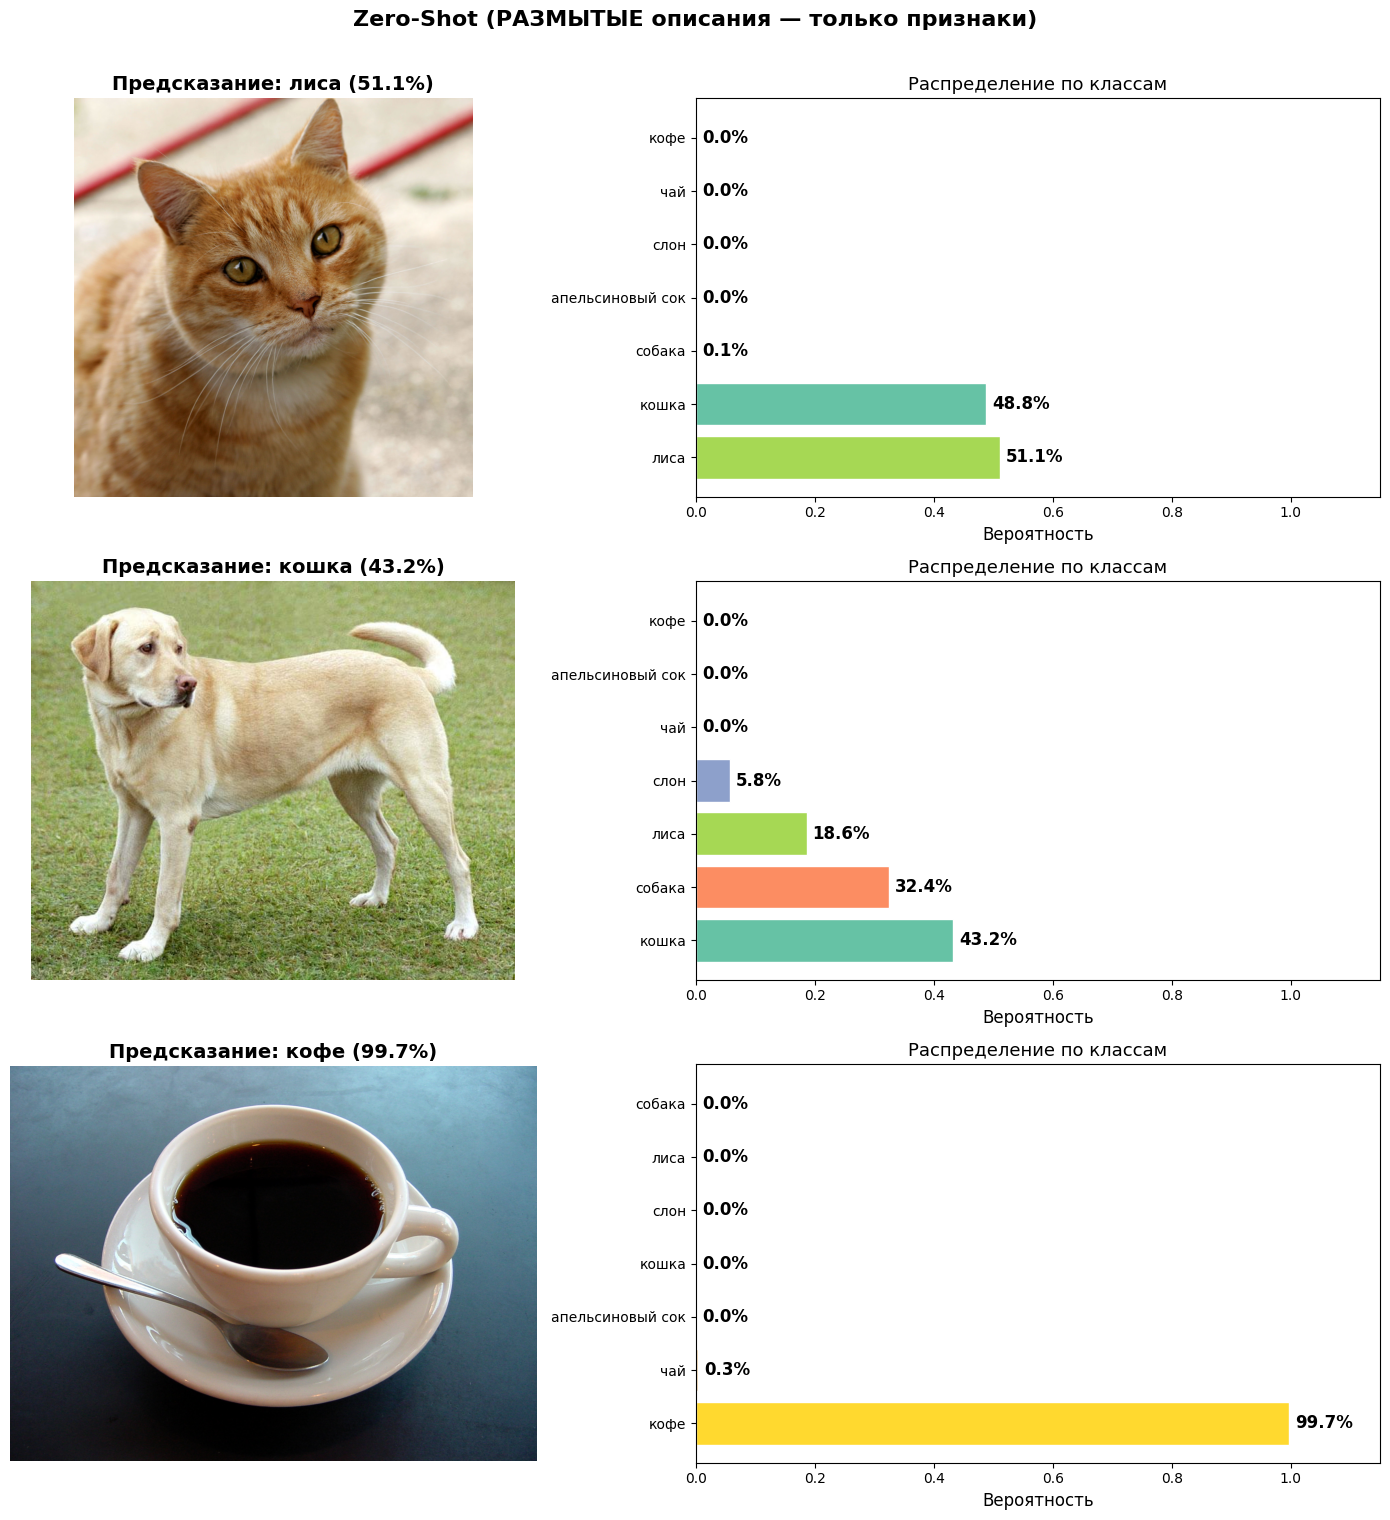

In [13]:
# === РАЗМЫТЫЕ ОПИСАНИЯ — только признаки, без названий ===
classes_vague = {
    "кошка": "four legs, whiskers, triangular pointy ears, smaller than a dog, furry, retractable claws",
    "собака": "four legs, floppy ears, friendly face, wags tail, loyal companion, wet nose",
    "слон": "four legs, very large and heavy, long trunk, big floppy ears, grey thick skin, tusks",
    "лиса": "four legs, pointy snout, bushy fluffy tail, reddish orange fur, small and agile",
    "кофе": "small dark brown hot liquid in a white ceramic cup, steam rising, bitter aroma, beans",
    "чай": "transparent golden warm liquid in a cup, light color, herbal leaves, mild taste",
    "апельсиновый сок": "tall glass with ice, bright orange colored liquid, fruity, refreshing, citrus",
}

class_names_v = list(classes_vague.keys())
text_prompts_v = [f"a photo of {desc}" for desc in classes_vague.values()]

# Классификация и визуализация
n_images = len(images)
fig, axes = plt.subplots(n_images, 2, figsize=(14, 5 * n_images),
                         gridspec_kw={"width_ratios": [1, 1.3]})
if n_images == 1:
    axes = axes.reshape(1, -1)

colors_v = plt.cm.Set2(np.linspace(0, 1, len(class_names_v)))

for i, img in enumerate(images):
    inputs = processor(text=text_prompts_v, images=img, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = outputs.logits_per_image[0].softmax(dim=0).cpu().numpy()

    best_idx = probs.argmax()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Предсказание: {class_names_v[best_idx]} ({probs[best_idx]:.1%})",
                         fontsize=14, fontweight="bold")
    axes[i, 0].axis("off")

    sorted_idx = np.argsort(probs)[::-1]
    bars = axes[i, 1].barh(
        [class_names_v[j] for j in sorted_idx],
        [probs[j] for j in sorted_idx],
        color=[colors_v[j] for j in sorted_idx],
        edgecolor="white",
    )
    for bar, j in zip(bars, sorted_idx):
        axes[i, 1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                        f"{probs[j]:.1%}", va="center", fontsize=12, fontweight="bold")
    axes[i, 1].set_xlim(0, 1.15)
    axes[i, 1].set_xlabel("Вероятность", fontsize=12)
    axes[i, 1].set_title("Распределение по классам", fontsize=13)

plt.suptitle("Zero-Shot (РАЗМЫТЫЕ описания — только признаки)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()